# Ejercicio 2

In [16]:
import pyvo as vo
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as sp
import numpy as np

# Preliminares

## Primero, creamos la tabla con los datos que vamos a necesitar para realizar el ejercicio

In [17]:
# seleccionamos el servidor a partir del cual vamos a buscar los datos
service = vo.dal.TAPService("http://voparis-tap-planeto.obspm.fr/tap")

#extraemos los datos que necesitamos de la base de datos exoplanet.eu con las condiciones indicadas. 
query = """SELECT obs_id,granule_uid,mass,period,semi_major_axis,
            star_spec_type,detection_type FROM exoplanet.epn_core 
            WHERE mass < 15""" #masa menor a 15 masas jupiterianas, para no considerar enanas marrones

# realizamos la consulta
results = service.search(query) 


# convertimos a tabla de astropy    

table = results.to_table()

# convertimos a dataframe de pandas

df = table.to_pandas()

df.set_index('granule_uid',inplace = True) #aca reemplazo el indice por el nombre del planeta

df

df.to_csv('datos.csv') #aca guardamos la tabla


Creamos subtablas pues nos hara mas facil el trabajar unicamente con los datos que necesitemos para realizar un grafico en particular.

In [18]:
RV = df.loc[:, 'detection_type'] == 'Radial Velocity' # condicion para seleccionar los datos que necesitamos
df_RV = df.loc[RV] # dataframe con los datos que cumplen la condicion
df_RV.head() # mostramos las primeras filas del dataframe

,obs_id,mass,period,semi_major_axis,star_spec_type,detection_type
granule_uid,,,,,,
2M1510 (AB)b,10952,0.031,100.00000,NaN,,Radial Velocity
51 Peg b,12,0.470,4.23080,0.05200,G2IV-V,Radial Velocity
54 Psc b,38,0.230,62.25000,0.29500,K0 V,Radial Velocity
55 Cnc Ab,25,0.840,14.65314,0.11339,K0V,Radial Velocity
BD-17 63 b,512,5.325,655.60000,1.34000,K5V,Radial Velocity


Aca creamos una subtabla con las detecciones mediante velocidad radial, analogamente hacemos lo mismo con los otros metodos:

In [19]:
TRAN = df.loc[:, 'detection_type'] == 'Primary Transit'
df_TRAN = df.loc[TRAN]
IMA = df.loc[:, 'detection_type'] == 'Imaging'
df_IMA = df.loc[IMA]
Astrom = df.loc[:, 'detection_type'] == 'Astrometry'
df_Astrom = df.loc[Astrom]
ML = df.loc[:, 'detection_type'] == 'Microlensing'
df_ML = df.loc[ML]
Pulsar= df.loc[:, 'detection_type'] == 'Pulsar'
df_Pulsar = df.loc[Pulsar]
TTV = df.loc[:, 'detection_type'] == 'TTV'
df_TTV = df.loc[TTV]
Other = df.loc[:, 'detection_type'] == 'Other'
df_Other = df.loc[Other]

Ahora, graficamos masa vs periodo para las diferentes tecnicas de deteccion.

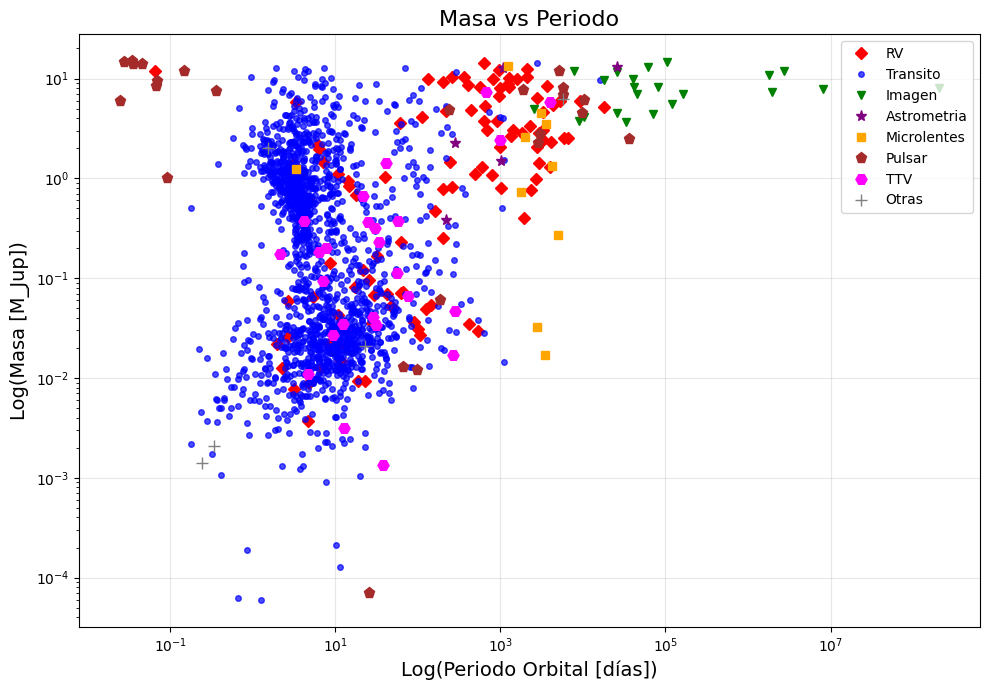

In [20]:
plt.figure(figsize=(10, 7))

plt.plot(df_RV['period'], df_RV['mass'], 'D', color='red', label='RV', markersize=6)
plt.plot(df_TRAN['period'], df_TRAN['mass'], 'o', color='blue', label='Transito', alpha=0.7, markersize=4)
plt.plot(df_IMA['period'], df_IMA['mass'], 'v', color='green', label='Imagen', markersize=6)
plt.plot(df_Astrom['period'], df_Astrom['mass'], '*', color='purple', label='Astrometria', markersize=8)
plt.plot(df_ML['period'], df_ML['mass'], 's', color='orange', label='Microlentes', markersize=6)
plt.plot(df_Pulsar['period'], df_Pulsar['mass'], 'p', color='brown', label='Pulsar', markersize=8)
plt.plot(df_TTV['period'], df_TTV['mass'], 'H', color='magenta', label='TTV', markersize=8)
plt.plot(df_Other['period'], df_Other['mass'], '+', color='gray', label='Otras', markersize=8)

plt.xscale('log')
plt.yscale('log')

plt.title('Masa vs Periodo', fontsize=16)
plt.xlabel('Log(Periodo Orbital [días])', fontsize=14)  # Cambiado
plt.ylabel('Log(Masa [M_Jup])', fontsize=14)  # Cambiado

plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ahora, graficamos la distribucion de masa y periodo (por separado) para las distintas tecnicas.

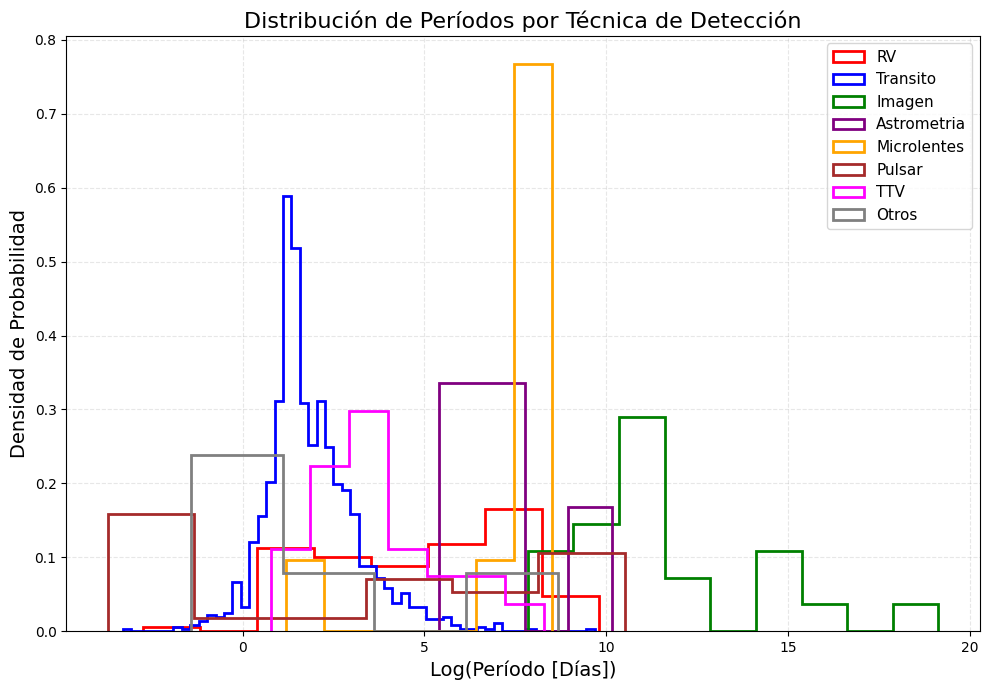

In [21]:
plt.figure(figsize=(10, 7))

plt.hist(np.log(df_RV['period']), bins='auto', density=True, histtype='step', 
         label='RV', lw=2, color='red')
plt.hist(np.log(df_TRAN['period']), bins='auto', density=True, histtype='step', 
         label='Transito', lw=2, color='blue')
plt.hist(np.log(df_IMA['period']), bins='auto', density=True, histtype='step', 
         label='Imagen', lw=2, color='green')
plt.hist(np.log(df_Astrom['period']), bins='auto', density=True, histtype='step', 
         label='Astrometria', lw=2, color='purple')
plt.hist(np.log(df_ML['period']), bins='auto', density=True, histtype='step', 
         label='Microlentes', lw=2, color='orange')
plt.hist(np.log(df_Pulsar['period']), bins='auto', density=True, histtype='step', 
         label='Pulsar', lw=2, color='brown')
plt.hist(np.log(df_TTV['period']), bins='auto', density=True, histtype='step', 
         label='TTV', lw=2, color='magenta')
plt.hist(np.log(df_Other['period']), bins='auto', density=True, histtype='step', 
         label='Otros', lw=2, color='gray')

plt.legend(fontsize=11, loc='best')
plt.title('Distribución de Períodos por Técnica de Detección', fontsize=16)
plt.xlabel('Log(Período [Días])', fontsize=14)
plt.ylabel('Densidad de Probabilidad', fontsize=14)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

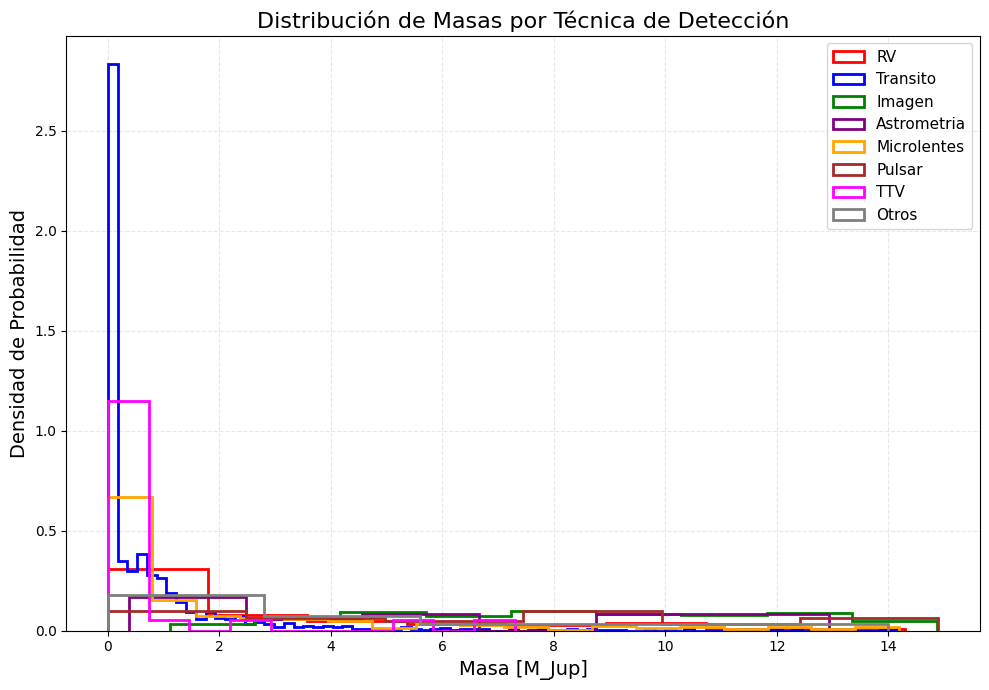

In [22]:
plt.figure(figsize=(10, 7))

plt.hist(df_RV['mass'], bins='auto', density=True, histtype='step', 
         label='RV', lw=2, color='red')
plt.hist(df_TRAN['mass'], bins='auto', density=True, histtype='step', 
         label='Transito', lw=2, color='blue')
plt.hist(df_IMA['mass'], bins='auto', density=True, histtype='step', 
         label='Imagen', lw=2, color='green')
plt.hist(df_Astrom['mass'], bins='auto', density=True, histtype='step', 
         label='Astrometria', lw=2, color='purple')
plt.hist(df_ML['mass'], bins='auto', density=True, histtype='step', 
         label='Microlentes', lw=2, color='orange')
plt.hist(df_Pulsar['mass'], bins='auto', density=True, histtype='step', 
         label='Pulsar', lw=2, color='brown')
plt.hist(df_TTV['mass'], bins='auto', density=True, histtype='step', 
         label='TTV', lw=2, color='magenta')
plt.hist(df_Other['mass'], bins='auto', density=True, histtype='step', 
         label='Otros', lw=2, color='gray')

plt.legend(fontsize=11, loc='best')
plt.title('Distribución de Masas por Técnica de Detección', fontsize=16)
plt.xlabel('Masa [M_Jup]', fontsize=14)
plt.ylabel('Densidad de Probabilidad', fontsize=14)  # Cambiado a Densidad
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()